In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
plt.style.use('seaborn')


In [2]:
data = pd.read_csv("G:/python/data/dow/data.csv", index_col='Date', parse_dates=True)
data.head()

,MMM,AXP,AAPL,BA,CAT,CVX,CSCO,KO,DIS,DWDP,...,PFE,PG,TRV,UTX,UNH,VZ,V,WMT,WBA,^DJI
Date,,,,,,,,,,,,,,,,,,,,,
2009-12-29,84.129997,40.880001,7.467857,55.209999,58.180000,77.209999,24.100000,28.870001,32.380001,NaN,...,17.609108,61.580002,49.869999,NaN,30.850000,31.353628,22.004999,54.110001,37.230000,10545.410156
2009-12-30,83.900002,40.799999,7.558571,54.959999,58.049999,77.650002,24.180000,28.840000,32.279999,NaN,...,17.552181,61.369999,50.259998,NaN,31.010000,31.344250,22.035000,54.299999,37.130001,10548.509766
2009-12-31,82.669998,40.520000,7.526071,54.130001,56.990002,76.989998,23.940001,28.500000,32.250000,NaN,...,17.258064,60.630001,49.860001,NaN,30.480000,31.072264,21.865000,53.450001,36.720001,10428.049805
2010-01-04,83.019997,40.919998,7.643214,56.180000,58.549999,79.059998,24.690001,28.520000,32.070000,NaN,...,17.960152,61.119999,49.810001,NaN,31.530001,31.212946,22.035000,54.230000,37.299999,10583.959961
2010-01-05,82.500000,40.830002,7.656429,58.020000,59.250000,79.620003,24.580000,28.174999,31.990000,NaN,...,17.703985,61.139999,48.630001,NaN,31.480000,31.269218,21.782499,53.689999,37.000000,10572.019531


In [3]:
data.tail()

,MMM,AXP,AAPL,BA,CAT,CVX,CSCO,KO,DIS,DWDP,...,PFE,PG,TRV,UTX,UNH,VZ,V,WMT,WBA,^DJI
Date,,,,,,,,,,,,,,,,,,,,,
2021-02-26,175.059998,135.259995,121.260002,212.009995,215.880005,100.000000,44.869999,48.990002,189.039993,NaN,...,33.490002,123.529999,145.500000,NaN,332.220001,55.299999,212.389999,129.919998,47.930000,30932.369141
2021-03-01,176.410004,138.710007,127.790001,224.389999,219.759995,102.050003,45.919998,49.900002,194.979996,NaN,...,33.689999,124.290001,150.389999,NaN,334.649994,55.360001,216.630005,131.369995,47.849998,31535.509766
2021-03-02,177.110001,139.250000,125.120003,223.139999,215.820007,102.440002,45.520000,50.099998,193.940002,NaN,...,33.509998,123.900002,149.119995,NaN,334.640015,54.980000,215.770004,130.110001,47.439999,31391.519531
2021-03-03,178.059998,142.589996,122.059998,228.559998,214.910004,103.589996,45.130001,49.980000,192.259995,NaN,...,34.389999,123.160004,150.710007,NaN,332.869995,55.380001,214.850006,127.589996,47.630001,31270.089844
2021-03-04,177.630005,142.679993,120.129997,224.710007,212.770004,104.500000,44.560001,49.939999,188.029999,NaN,...,34.200001,122.150002,149.020004,NaN,333.809998,54.799999,211.500000,127.529999,46.860001,30924.140625


In [3]:
dow = data[['^DJI']]
data = data.drop(['DWDP', 'UTX', '^DJI'], axis = 1)

In [17]:
ret = data.pct_change().dropna().mean() * 250   # annualize
std = data.pct_change().dropna().std() * np.sqrt(250)   # annualized
mkrs = ret.index.tolist()

Text(0.5, 1.0, 'Return vs. Std in Dow')

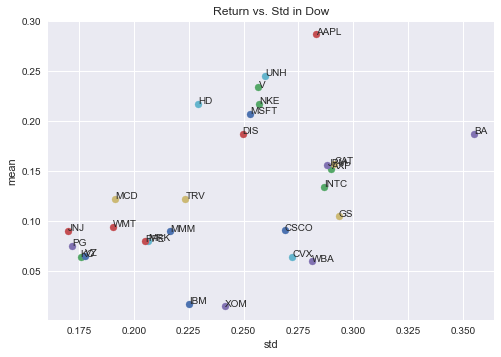

In [21]:
for i in range(len(ret)):
    plt.scatter(std[i], ret[i])
    plt.annotate(mkrs[i], (std[i], ret[i]))
plt.xlabel('std')
plt.ylabel('mean') 
plt.title("Return vs. Std in Dow")   

### KMeans clustering 

In [5]:
dir(data.cov)

['__call__',
 '__class__',
 '__delattr__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__func__',
 '__ge__',
 '__get__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__self__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__']

In [ ]:
### oops in python 

class Test:
    def __init__(self, n):
        pass   

    def build(self, input_shape):
        pass 
    def call(self, x):
        return x **2 

In [27]:
from sklearn.cluster import KMeans 

kmeans = KMeans()   # instantiation 

In [35]:
df= pd.DataFrame().assign(ret=ret, std=std)

In [43]:
elbow_score = []
for k in range(5, 25):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(df)
    elbow_score.append(kmeans.inertia_)   # cluster's coherence

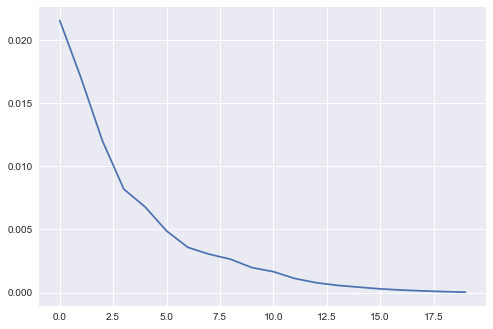

In [44]:
plt.plot(elbow_score)

In [87]:
# based on elbow score 

#k = 10
k = 3
kmeans = KMeans(n_clusters=k)
kmeans.fit(df)
centeroid = kmeans.cluster_centers_



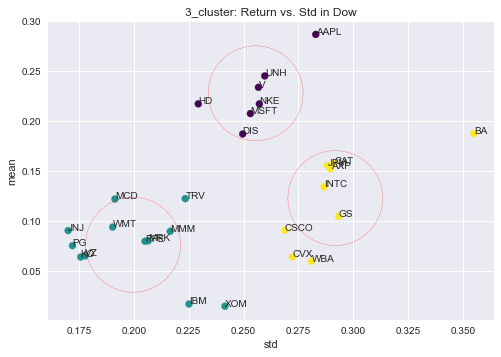

In [99]:
plt.scatter(df['std'], df['ret'], c=kmeans.labels_, cmap='viridis')
plt.xlabel('std')
plt.ylabel('mean') 
plt.title(f"{k}_cluster: Return vs. Std in Dow")   

mkrs = ret.index.tolist()
for i in range(len(df)):
    plt.annotate(mkrs[i], (std[i], ret[i]))

for i in range(len(centeroid)):
    plt.scatter(centeroid[i, 1], centeroid[i, 0], s=9000, marker='o', linestyle="--", edgecolor='r', facecolors="none")


### Cluster with eigenvalue

In [115]:
df_2 = data.pct_change().dropna()

In [116]:
df_2.describe()

,MMM,AXP,AAPL,BA,CAT,CVX,CSCO,KO,DIS,XOM,...,MSFT,NKE,PFE,PG,TRV,UNH,VZ,V,WMT,WBA
count,2813.000000,2813.000000,2813.000000,2813.000000,2813.000000,2813.000000,2813.000000,2813.000000,2813.000000,2813.000000,...,2813.000000,2813.000000,2813.000000,2813.000000,2813.000000,2813.000000,2813.000000,2813.000000,2813.000000,2813.000000
mean,0.000360,0.000611,0.001148,0.000751,0.000631,0.000257,0.000364,0.000257,0.000750,0.000060,...,0.000831,0.000870,0.000320,0.000303,0.000491,0.000982,0.000262,0.000936,0.000377,0.000240
std,0.013698,0.018317,0.017891,0.022448,0.018428,0.017218,0.017003,0.011119,0.015787,0.015274,...,0.016009,0.016267,0.012971,0.010883,0.014131,0.016422,0.011251,0.016240,0.012039,0.017769
min,-0.129450,-0.148187,-0.128647,-0.238484,-0.142822,-0.221248,-0.162107,-0.096725,-0.129846,-0.122248,...,-0.147390,-0.116667,-0.077346,-0.087373,-0.208004,-0.172769,-0.066205,-0.135472,-0.101832,-0.143374
25%,-0.005324,-0.006519,-0.007188,-0.008570,-0.008287,-0.007314,-0.006649,-0.004720,-0.006298,-0.006813,...,-0.006951,-0.006987,-0.006033,-0.004696,-0.005618,-0.007006,-0.006025,-0.006906,-0.005182,-0.008029
50%,0.000706,0.000699,0.000893,0.000764,0.000392,0.000400,0.000455,0.000433,0.000600,-0.000122,...,0.000673,0.000688,0.000000,0.000327,0.000848,0.000866,0.000496,0.001313,0.000437,0.000263
75%,0.007019,0.008625,0.010384,0.009830,0.010023,0.007722,0.008058,0.005711,0.007874,0.007085,...,0.008636,0.008830,0.006672,0.005482,0.007056,0.008706,0.006388,0.008848,0.006005,0.009161
max,0.125986,0.218823,0.119808,0.243186,0.103321,0.227407,0.159505,0.064796,0.144123,0.126868,...,0.142169,0.151752,0.089607,0.120090,0.132903,0.127989,0.076802,0.149973,0.117085,0.126036


In [117]:
eVal0, eVec0 = np.linalg.eigh(df_2.cov())

In [118]:
weights = eVec0[:, -1] / np.sum(eVec0[:, -1])

In [125]:
np.dot(df_2, weights.T)

array([ 0.00076818, -0.00848404,  0.01554493, ..., -0.00522018,
        0.00063723, -0.00934749])

In [132]:
ret2 = (df_2 * weights).mean()  * 250 
std2 = (df_2 * weights).std() * np.sqrt(250)

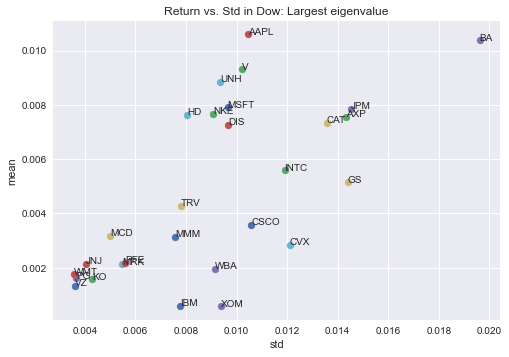

In [147]:
for i in range(len(ret2)):
    plt.scatter(std2[i], ret2[i])
    plt.annotate(mkrs[i], (std2[i], ret2[i]))
plt.xlabel('std')
plt.ylabel('mean') 
plt.title("Return vs. Std in Dow: Largest eigenvalue"); 

In [136]:
df2= pd.DataFrame().assign(ret=ret2, std=std2)

In [139]:
k = 3
kmeans2 = KMeans(n_clusters=k)
kmeans2.fit(df2)
centeroid2 = kmeans2.cluster_centers_



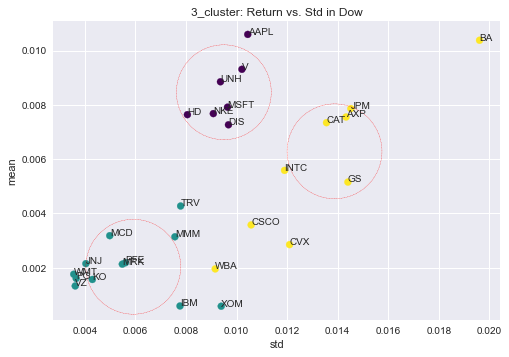

In [141]:
plt.scatter(df2['std'], df2['ret'], c=kmeans.labels_, cmap='viridis')
plt.xlabel('std')
plt.ylabel('mean') 
plt.title(f"{k}_cluster: Return vs. Std in Dow")   

mkrs = ret.index.tolist()
for i in range(len(df2)):
    plt.annotate(mkrs[i], (std2[i], ret2[i]))

for i in range(len(centeroid)):
    plt.scatter(centeroid2[i, 1], centeroid2[i, 0], s=9000, marker='o', linestyle="--", edgecolor='r', facecolors="none")


In [148]:
print(ret2.mean()/std2.mean())

0.5348936224882841


In [149]:
print(ret.mean()/std.mean())

0.5321225067001495
